100%|██████████| 1462/1462 [00:16<00:00, 89.99it/s]


✔ scale_map 저장 완료


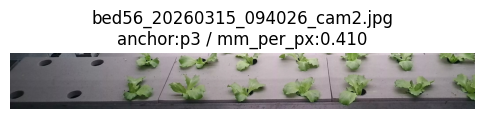

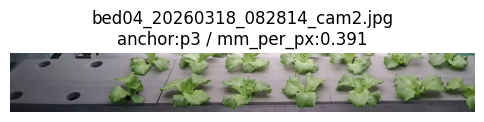

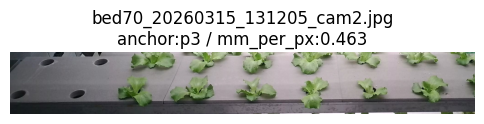

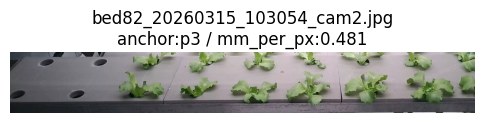

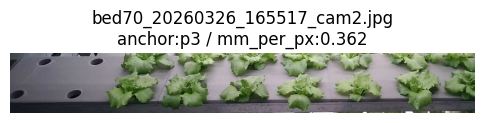

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import random
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# =========================
# 경로 설정
# =========================
IMG_DIR = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/0306-0402_2"   # 이미지 폴더 (이 변수는 이제 process_one 내부에서는 직접 사용되지 않습니다.)
CSV_PATH = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/1. circle_anchor/_circle_anchor_test_final/per_image_results_v3.csv"
OUT_CSV = "/content/drive/Othercomputers/내 컴퓨터/새 폴더/양상추사진/양상추_테라웨이브/양상추 날짜/RGB_정면/2. ROI_BOX/2작기/4. scale/scale_map.csv"

REAL_DIAMETER_MM = 50  # 5cm

# =========================
# 원 검출 함수 (ROI 기반)
# =========================
def detect_circle_diameter(img, cx, cy, roi_size=120):
    h, w = img.shape[:2]

    x1 = max(0, int(cx - roi_size//2))
    y1 = max(0, int(cy - roi_size//2))
    x2 = min(w, int(cx + roi_size//2))
    y2 = min(h, int(cy + roi_size//2))

    roi = img[y1:y2, x1:x2]
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (9,9), 2)

    circles = cv2.HoughCircles(
        gray,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=30,
        param1=100,
        param2=20,
        minRadius=10,
        maxRadius=80
    )

    if circles is not None:
        circles = np.uint16(np.around(circles))
        r = circles[0][0][2]
        return r * 2  # diameter
    else:
        return None

# =========================
# 1장 처리
# =========================
def process_one(row):
    # 이미지 경로를 subfolder 컬럼과 image_name 컬럼을 사용하여 구성
    # subfolder 컬럼이 전체 경로를 포함한다고 가정
    img_path = os.path.join(row['subfolder'], row['image_name'])

    if not os.path.exists(img_path):
        return None

    img = cv2.imread(img_path)

    anchors = [
        ('p3', row['p3_x'], row['p3_y']),
        ('p4', row['p4_x'], row['p4_y']),
        ('p2', row['p2_x'], row['p2_y'])
    ]

    diameter = None
    anchor_used = None

    for name, x, y in anchors:
        if pd.isna(x) or pd.isna(y):
            continue

        d = detect_circle_diameter(img, x, y)
        if d is not None:
            diameter = d
            anchor_used = name
            break

    if diameter is None:
        return {
            "image_name": row['image_name'],
            "mm_per_px": None,
            "diameter_px": None,
            "anchor": None,
            "qc": "fail",
            "subfolder": row['subfolder'] # subfolder 정보 추가
        }

    mm_per_px = REAL_DIAMETER_MM / diameter

    return {
        "image_name": row['image_name'],
        "mm_per_px": mm_per_px,
        "diameter_px": diameter,
        "anchor": anchor_used,
        "qc": "ok",
        "subfolder": row['subfolder'] # subfolder 정보 추가
    }

# =========================
# 실행
# =========================
df = pd.read_csv(CSV_PATH)

results = []

with ThreadPoolExecutor(max_workers=8) as executor:
    futures = [executor.submit(process_one, row) for _, row in df.iterrows()]
    for f in tqdm(futures):
        res = f.result()
        if res: # Only append if res is not None or empty (which a dict won't be)
            results.append(res)

scale_df = pd.DataFrame(results)
scale_df.to_csv(OUT_CSV, index=False)

print("✔ scale_map 저장 완료")

# =========================
# 시각화 (랜덤 5장)
# =========================
import matplotlib.pyplot as plt

# Check if scale_df is empty before attempting to sample
if not scale_df.empty:
    sample = scale_df.dropna().sample(5)

    for _, row in sample.iterrows():
        # 시각화에도 올바른 이미지 경로 사용
        img_to_show_path = os.path.join(row['subfolder'], row['image_name'])
        img = cv2.imread(img_to_show_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(6,4))
        plt.imshow(img)
        plt.title(f"{row['image_name']}\nanchor:{row['anchor']} / mm_per_px:{row['mm_per_px']:.3f}")
        plt.axis('off')
        plt.show()
else:
    print("⚠ 시각화할 데이터가 없습니다. 처리된 이미지나 유효한 스케일 정보가 없습니다.")

In [5]:
scale_df['mm_per_px'].describe()

,mm_per_px
count,1443.000000
mean,0.455014
std,0.153538
min,0.320513
25%,0.396825
50%,0.431034
75%,0.471698
max,2.272727


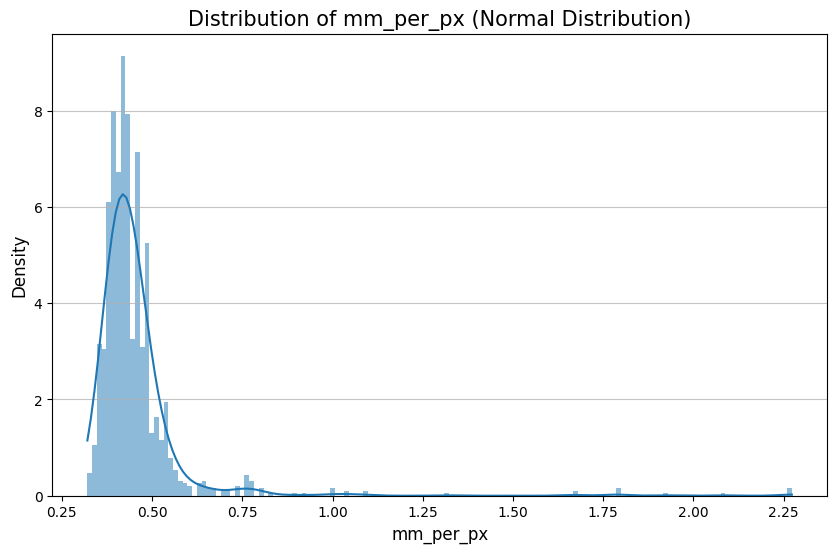

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

if not scale_df.empty and 'mm_per_px' in scale_df.columns:
    # NaN 값 제거 및 유효한 데이터만 사용
    data_for_plot = scale_df['mm_per_px'].dropna()

    if not data_for_plot.empty:
        plt.figure(figsize=(10, 6))
        sns.histplot(data_for_plot, kde=True, stat='density', linewidth=0)
        plt.title('Distribution of mm_per_px (Normal Distribution)', fontsize=15)
        plt.xlabel('mm_per_px', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.grid(axis='y', alpha=0.75)
        plt.show()
    else:
        print("⚠ 'mm_per_px' 컬럼에 유효한 데이터가 없습니다.")
else:
    print("⚠ 'scale_df'가 비어 있거나 'mm_per_px' 컬럼이 없습니다.")